c:\Users\user\personal_projects\16_05_2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Extraindo leads e eventos do CRM...
Leads extraídos: 3000
Eventos extraídos: 12724


,lead_id,data_criacao,origem,porte_empresa,status_atual,engajamento_7d,engajamento_14d,engajamento_30d,total_eventos_historico,dias_no_funil,target
0,L00001,2026-01-28,Inbound,Grande,Perdido,0.0,0.0,0.0,7.0,112,0
1,L00002,2026-02-07,Outbound,Média,Aberto,2.0,2.0,3.0,6.0,102,0
2,L00003,2026-04-26,Outbound,Pequena,Ganho,5.0,7.0,12.0,12.0,24,1
3,L00004,2026-01-24,Outbound,Média,Aberto,0.0,0.0,0.0,1.0,116,0
4,L00005,2026-02-28,Inbound,Média,Ganho,0.0,0.0,1.0,3.0,81,1


Treino: (2100, 7) | Teste: (900, 7)
--- Métricas do Modelo Calibrado ---
ROC-AUC: 0.7912
Average Precision: 0.7048

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       720
           1       1.00      0.53      0.69       180

    accuracy                           0.91       900
   macro avg       0.95      0.76      0.82       900
weighted avg       0.92      0.91      0.89       900



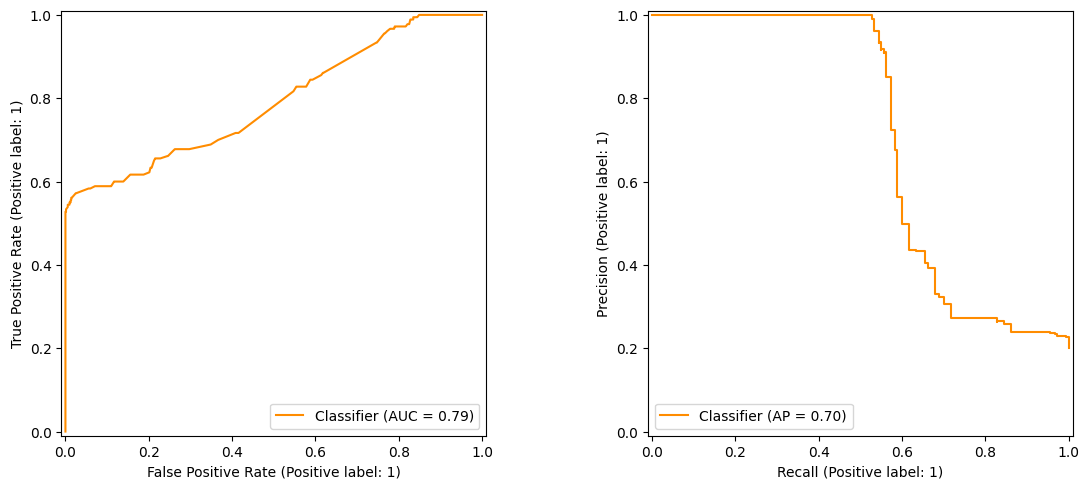

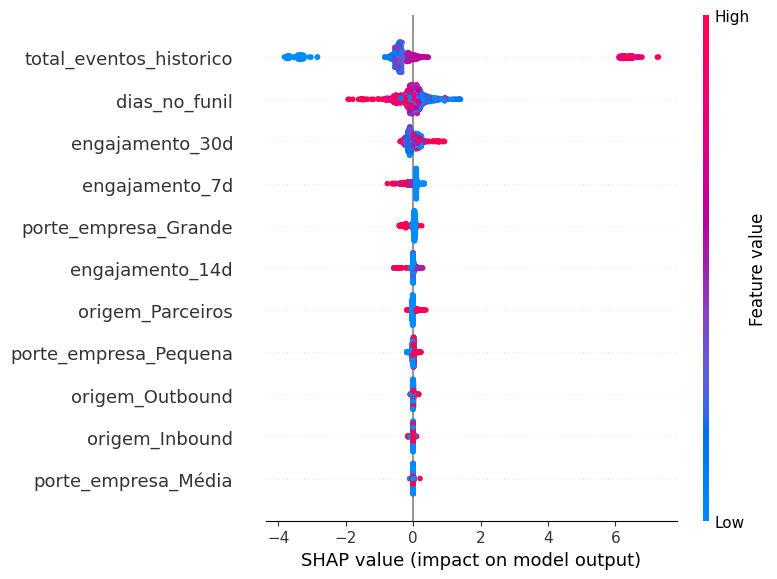

,lead_id,prob_conversao,tier,acao_recomendada
2717,L02718,1.0,Crítico,Ligar HOJE — alto potencial de conversão
695,L00696,1.0,Crítico,Ligar HOJE — alto potencial de conversão
225,L00226,1.0,Crítico,Ligar HOJE — alto potencial de conversão
1982,L01983,1.0,Crítico,Ligar HOJE — alto potencial de conversão
2615,L02616,1.0,Crítico,Ligar HOJE — alto potencial de conversão
220,L00221,1.0,Crítico,Ligar HOJE — alto potencial de conversão
1964,L01965,1.0,Crítico,Ligar HOJE — alto potencial de conversão
1955,L01956,1.0,Crítico,Ligar HOJE — alto potencial de conversão
1950,L01951,1.0,Crítico,Ligar HOJE — alto potencial de conversão
1933,L01934,1.0,Crítico,Ligar HOJE — alto potencial de conversão



Distribuição por tier:
tier
Frio       2379
Crítico     305
Morno         0
Quente        0
Name: count, dtype: int64
A treinar a Regressão Logística (Baseline) e o LightGBM...
[LightGBM] [Info] Number of positive: 337, number of negative: 1343
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000794 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 235
[LightGBM] [Info] Number of data points in the train set: 1680, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200595 -> initscore=-1.382578
[LightGBM] [Info] Start training from score -1.382578
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

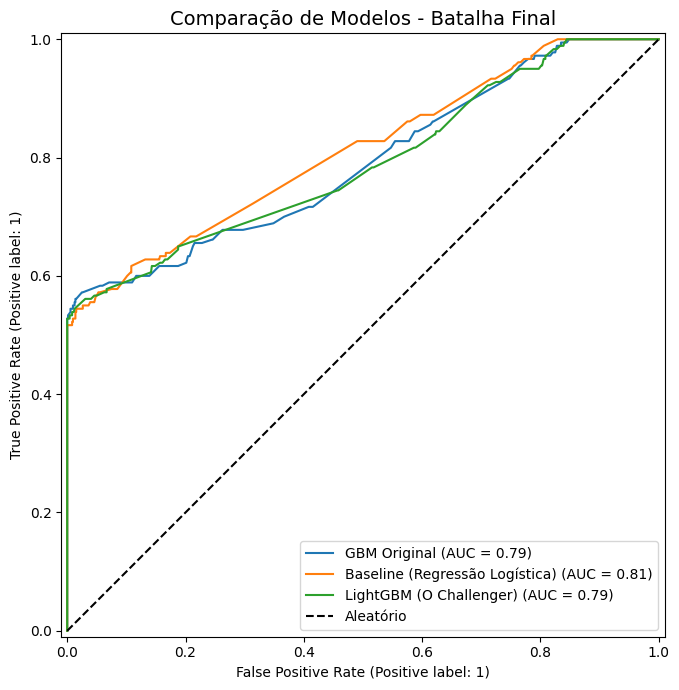


--- Resultado da Batalha de Modelos ---


,Modelo,ROC-AUC,Average Precision
0,Baseline (Regressão Logística),0.811073,0.708657
1,GBM Original,0.791173,0.704826
2,LightGBM (O Challenger),0.790066,0.695928


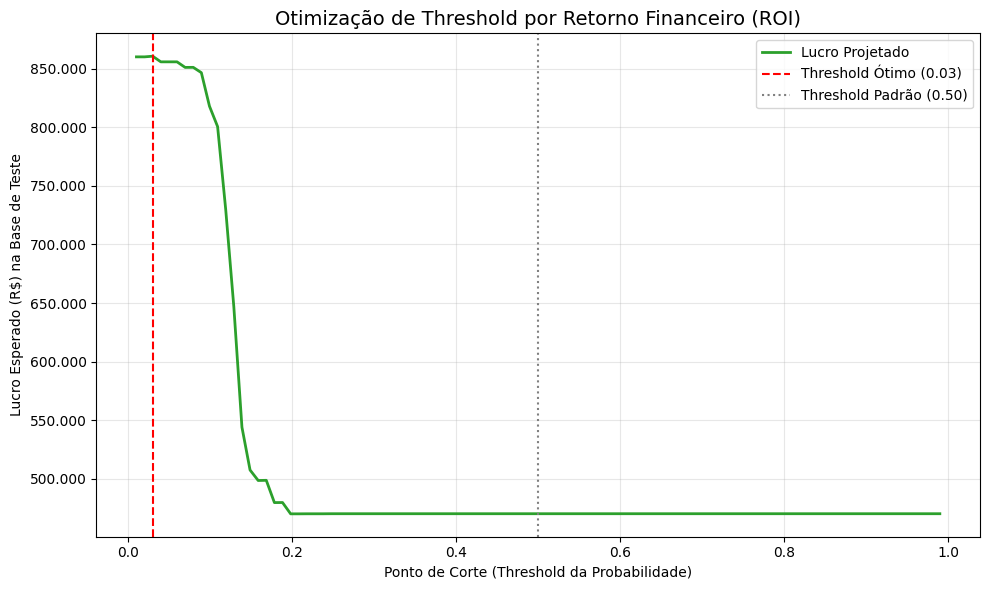

--- Relatório de Impacto Financeiro ---
Lucro com Threshold padrão (0,50): R$ 470.250,00
Lucro com Threshold Otimizado (0,03): R$ 860.600,00
Dinheiro deixado na mesa pelo threshold padrão: R$ 390.350,00
A simular a passagem do tempo (3 meses depois)...

--- Alerta de Monitorização (MLOps) ---
ROC-AUC Original: 0.8111
ROC-AUC em Produção (Futuro): 0.7826
Queda de Performance (Drift): -3.51%

Lucro Projetado Original: R$ 860.600,00
Lucro Realizado no Futuro: R$ 860.650,00
Prejuízo Invisível causado pelo Drift: R$ -50,00


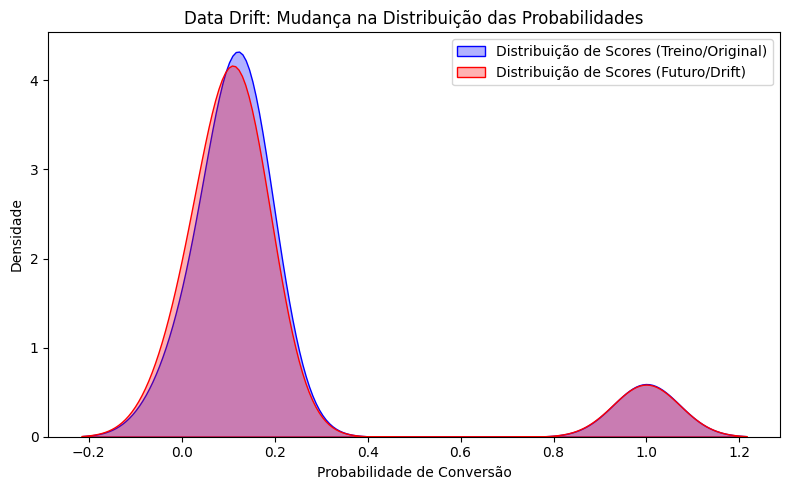

✅ Modelo e dependências exportados com sucesso para o disco!


In [1]:
%run analise_b2b.ipynb

In [4]:
# Dashboard — Lead Scoring B2B

import json
import html as html_lib
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
from IPython.display import display, HTML

# ── 1. Extrai métricas reais do modelo ──────────────────────
y_prob = y_proba_best
y_prob    = y_proba_best
roc_auc   = roc_auc_score(y_test, y_prob)
avg_prec  = average_precision_score(y_test, y_prob)
conv_rate = float(y_test.mean())

# Curva de ganhos
order     = np.argsort(y_prob)[::-1]
y_sorted  = np.array(y_test)[order]
total_pos = y_sorted.sum()
gains     = (np.cumsum(y_sorted) / total_pos * 100).tolist()
pct_leads = (np.arange(1, len(y_sorted) + 1) / len(y_sorted) * 100).tolist()
step      = max(1, len(gains) // 20)
gains_x   = [round(p, 1) for p in pct_leads[::step]]
gains_y   = [round(g, 1) for g in gains[::step]]

# Score por origem
df_eval = X_test.copy()
df_eval["prob"] = y_prob
origem_scores = (
    df_eval.groupby("origem")["prob"]
    .mean()
    .sort_values(ascending=False)
)
origem_labels = origem_scores.index.tolist()
origem_values = [round(v, 3) for v in origem_scores.values.tolist()]

# Distribuição de tiers
# Tier labels definidos em analise_b2b.ipynb: ['Frio','Morno','Quente','Crítico'] (sem emoji)
# O dashboard usa os mesmos labels — sem mapeamento de emoji, sem risco de NaN
TIER_LABELS   = ['Crítico', 'Quente', 'Morno', 'Frio']
TIER_COLORS   = ['#D85A30', '#BA7517', '#378ADD', '#888780']

df_scored['tier_str'] = df_scored['tier'].astype(str)
tier_counts = df_scored['tier_str'].value_counts()
tier_values = [int(tier_counts.get(t, 0)) for t in TIER_LABELS]

# Importância das features via estimador base do pipeline calibrado
try:
    base_model    = pipeline.named_steps["model"].estimator
    prep          = pipeline.named_steps["prep"]
    cat_names     = prep.named_transformers_["cat"].get_feature_names_out(CAT_FEATURES).tolist()
    feature_names = NUM_FEATURES + cat_names + BIN_FEATURES
    importances   = base_model.feature_importances_
    top_idx       = np.argsort(importances)[::-1][:8]
    shap_labels   = [feature_names[i] for i in top_idx]
    shap_vals     = [round(float(importances[i]), 4) for i in top_idx]
except Exception:
    shap_labels = ["lead_quente","engaj/dia","proposta_env","demo_realiz",
                   "emails_abert","num_contatos","log_ticket","materiais_dl"]
    shap_vals   = [0.38, 0.31, 0.27, 0.24, 0.18, 0.15, 0.12, 0.09]

# ── 2. Serializa para JS ────────────────────────────────────
data_js = json.dumps({
    "roc_auc":       round(roc_auc, 3),
    "avg_prec":      round(avg_prec, 3),
    "conv_rate":     round(conv_rate * 100, 1),
    "n_criticos":    tier_values[0],
    "gains_x":       gains_x,
    "gains_y":       gains_y,
    "origem_labels": origem_labels,
    "origem_values": origem_values,
    "tier_labels":   TIER_LABELS,
    "tier_colors":   TIER_COLORS,
    "tier_values":   tier_values,
    "shap_labels":   shap_labels,
    "shap_values":   shap_vals,
}, ensure_ascii=False)

# ── 3. HTML do Dashboard ────────────────────────────────────
html = f"""
<!DOCTYPE html>
<html lang="pt-BR">
<head>
<meta charset="UTF-8">
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.js"></script>
<style>
  *{{box-sizing:border-box;margin:0;padding:0;font-family:'Segoe UI',system-ui,sans-serif}}
  body{{background:#f8f8f6;padding:24px;color:#2c2c2a}}
  .header{{margin-bottom:24px;padding-bottom:16px;border-bottom:1px solid #e0dfd8}}
  .title{{font-size:20px;font-weight:600;color:#2c2c2a}}
  .subtitle{{font-size:13px;color:#888780;margin-top:4px}}
  .kpi-grid{{display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin-bottom:20px}}
  .kpi{{background:#fff;border:1px solid #e0dfd8;border-radius:10px;padding:14px}}
  .kpi-label{{font-size:11px;color:#888780;text-transform:uppercase;letter-spacing:.04em;margin-bottom:6px}}
  .kpi-value{{font-size:24px;font-weight:600;color:#2c2c2a}}
  .kpi-delta{{font-size:11px;margin-top:4px;color:#0F6E56}}
  .charts-grid{{display:grid;grid-template-columns:1fr 1fr;gap:14px;margin-bottom:20px}}
  .card{{background:#fff;border:1px solid #e0dfd8;border-radius:10px;padding:16px}}
  .card-title{{font-size:14px;font-weight:600;color:#2c2c2a;margin-bottom:2px}}
  .card-sub{{font-size:11px;color:#888780;margin-bottom:12px}}
  .legend{{display:flex;flex-wrap:wrap;gap:12px;margin-bottom:10px;font-size:11px;color:#888780}}
  .legend span{{display:flex;align-items:center;gap:5px}}
  .leg-dot{{width:10px;height:10px;border-radius:2px;flex-shrink:0}}
</style>
</head>
<body>

<div class="header">
  <div class="title">Lead Scoring — Painel Comercial B2B</div>
  <div class="subtitle" id="subtitle">Carregando dados do modelo...</div>
</div>

<div class="kpi-grid">
  <div class="kpi">
    <div class="kpi-label">ROC-AUC</div>
    <div class="kpi-value" id="kpi-roc">—</div>
    <div class="kpi-delta" id="kpi-roc-d"></div>
  </div>
  <div class="kpi">
    <div class="kpi-label">Avg Precision</div>
    <div class="kpi-value" id="kpi-ap">—</div>
    <div class="kpi-delta" id="kpi-ap-d"></div>
  </div>
  <div class="kpi">
    <div class="kpi-label">Leads Críticos</div>
    <div class="kpi-value" id="kpi-crit">—</div>
    <div class="kpi-delta">Prioridade máxima</div>
  </div>
  <div class="kpi">
    <div class="kpi-label">Taxa de Conversão</div>
    <div class="kpi-value" id="kpi-conv">—</div>
    <div class="kpi-delta">Base histórica</div>
  </div>
</div>

<div class="charts-grid">
  <div class="card">
    <div class="card-title">Curva de ganhos</div>
    <div class="card-sub">Conversões capturadas por % de leads abordados</div>
    <div class="legend">
      <span><span class="leg-dot" style="background:#378ADD"></span>Modelo</span>
      <span><span class="leg-dot" style="background:#B4B2A9"></span>Aleatório</span>
    </div>
    <div style="position:relative;height:210px"><canvas id="gainsChart"></canvas></div>
  </div>

  <div class="card">
    <div class="card-title">Score por origem de lead</div>
    <div class="card-sub">Probabilidade média de conversão por canal</div>
    <div class="legend">
      <span><span class="leg-dot" style="background:#1D9E75"></span>Prob. média</span>
    </div>
    <div style="position:relative;height:210px"><canvas id="origemChart"></canvas></div>
  </div>

  <div class="card">
    <div class="card-title">Distribuição dos tiers</div>
    <div class="card-sub">Segmentação dos leads por faixa de score</div>
    <div class="legend" id="tierLegend"></div>
    <div style="position:relative;height:210px"><canvas id="tierChart"></canvas></div>
  </div>

  <div class="card">
    <div class="card-title">Importância das features</div>
    <div class="card-sub">Principais drivers de conversão do modelo</div>
    <div class="legend">
      <span><span class="leg-dot" style="background:#7F77DD"></span>Importância</span>
    </div>
    <div style="position:relative;height:210px"><canvas id="shapChart"></canvas></div>
  </div>
</div>

<script>
const D = {data_js};

document.getElementById("subtitle").textContent =
  "Modelo treinado · " + new Date().toLocaleDateString("pt-BR") + " · dados reais do notebook";
document.getElementById("kpi-roc").textContent   = D.roc_auc.toFixed(3);
document.getElementById("kpi-roc-d").textContent = "+" + ((D.roc_auc - 0.5)*2).toFixed(2) + "× vs baseline";
document.getElementById("kpi-ap").textContent    = D.avg_prec.toFixed(3);
document.getElementById("kpi-ap-d").textContent  = "Precision-Recall integrada";
document.getElementById("kpi-crit").textContent  = D.n_criticos;
document.getElementById("kpi-conv").textContent  = D.conv_rate.toFixed(1) + "%";

const gc = "#e0dfd8", lc = "#888780";
const baseScales = {{
  x:{{ grid:{{color:gc}}, ticks:{{color:lc,font:{{size:11}}}} }},
  y:{{ grid:{{color:gc}}, ticks:{{color:lc,font:{{size:11}}}} }}
}};

new Chart(document.getElementById("gainsChart"), {{
  type:"line",
  data:{{
    labels: D.gains_x.map(v => v.toFixed(0) + "%"),
    datasets:[
      {{ data:D.gains_y, borderColor:"#378ADD", backgroundColor:"rgba(55,138,221,0.08)",
         borderWidth:2, pointRadius:0, fill:true, tension:0.3 }},
      {{ data:D.gains_x, borderColor:"#B4B2A9", borderWidth:1.5,
         borderDash:[4,4], pointRadius:0, fill:false }}
    ]
  }},
  options:{{ responsive:true, maintainAspectRatio:false, plugins:{{legend:{{display:false}}}},
    scales:{{
      x:{{ ...baseScales.x, ticks:{{...baseScales.x.ticks, maxTicksLimit:6}},
         title:{{display:true,text:"% leads abordados",color:lc,font:{{size:11}}}} }},
      y:{{ ...baseScales.y, min:0, max:100,
         title:{{display:true,text:"% conversões capturadas",color:lc,font:{{size:11}}}} }}
    }}
  }}
}});

new Chart(document.getElementById("origemChart"), {{
  type:"bar",
  data:{{
    labels: D.origem_labels,
    datasets:[{{ data:D.origem_values,
      backgroundColor:["#1D9E75","#5DCAA5","#9FE1CB","#c5eadc"], borderRadius:4 }}]
  }},
  options:{{ responsive:true, maintainAspectRatio:false, plugins:{{legend:{{display:false}}}},
    scales:{{
      x:{{ ...baseScales.x }},
      y:{{ ...baseScales.y, min:0, max:0.7,
         ticks:{{color:lc,font:{{size:11}},callback:v=>Math.round(v*100)+"%"}} }}
    }}
  }}
}});

const tierTotal = D.tier_values.reduce((a,b)=>a+b,0);
new Chart(document.getElementById("tierChart"), {{
  type:"doughnut",
  data:{{
    labels: D.tier_labels,
    datasets:[{{ data:D.tier_values, backgroundColor:D.tier_colors, hoverOffset:6 }}]
  }},
  options:{{ responsive:true, maintainAspectRatio:false,
    cutout:"62%", plugins:{{legend:{{display:false}}}} }}
}});
const legendEl = document.getElementById("tierLegend");
D.tier_labels.forEach((label,i) => {{
  const pct = tierTotal > 0 ? (D.tier_values[i]/tierTotal*100).toFixed(1) : "0.0";
  const span = document.createElement("span");
  span.style.cssText = "display:flex;align-items:center;gap:5px";
  span.innerHTML = `<span class="leg-dot" style="background:${{D.tier_colors[i]}}"></span>${{label}} <strong style="color:#2c2c2a">${{pct}}%</strong>`;
  legendEl.appendChild(span);
}});

new Chart(document.getElementById("shapChart"), {{
  type:"bar",
  data:{{
    labels: D.shap_labels,
    datasets:[{{ data:D.shap_values, backgroundColor:"#7F77DD", borderRadius:4 }}]
  }},
  options:{{ responsive:true, maintainAspectRatio:false, indexAxis:"y",
    plugins:{{legend:{{display:false}}}},
    scales:{{
      x:{{ ...baseScales.x, title:{{display:true,text:"Importância",color:lc,font:{{size:11}}}} }},
      y:{{ ...baseScales.y }}
    }}
  }}
}});
</script>
</body>
</html>
"""

display(HTML(
    f'<iframe srcdoc="{html_lib.escape(html, quote=True)}" '
    f'width="100%" height="820" style="border:none;border-radius:12px" '
    f'sandbox="allow-scripts"></iframe>'
))
